Saving marketing.csv to marketing (2).csv
     TV      Radio  Social_Media       Sales
0  16.0   6.566231      2.907983   54.732757
1  13.0   9.237765      2.409567   46.677897
2  41.0  15.886446      2.913410  150.177829
3  83.0  30.020028      6.922304  298.246340
4  15.0   8.437408      1.405998   56.594181
<class 'pandas.core.frame.DataFrame'>
Index: 4546 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4546 non-null   float64
 1   Radio         4546 non-null   float64
 2   Social_Media  4546 non-null   float64
 3   Sales         4546 non-null   float64
dtypes: float64(4)
memory usage: 177.6 KB
None
                TV        Radio  Social_Media        Sales
count  4546.000000  4546.000000   4546.000000  4546.000000
mean     54.062912    18.157533      3.323473   192.413332
std      26.104942     9.663260      2.211254    93.019873
min      10.000000     0.000684      0.000031 

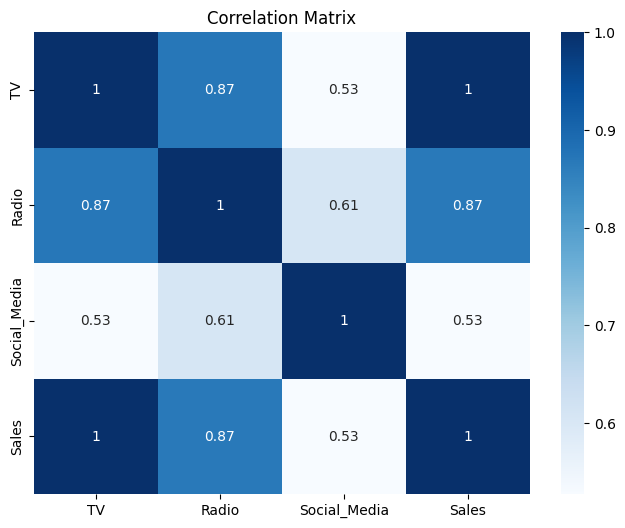

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:09:44   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

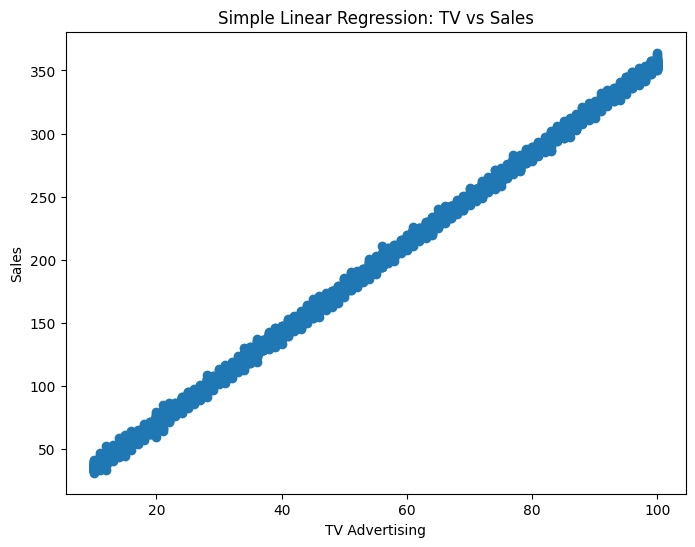

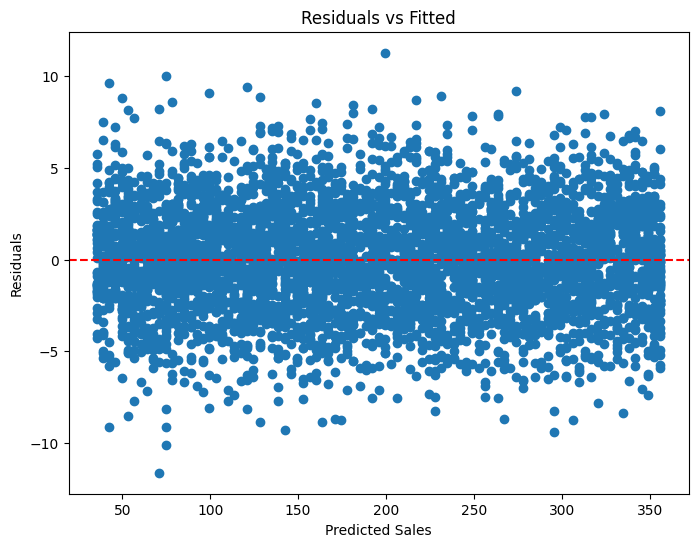

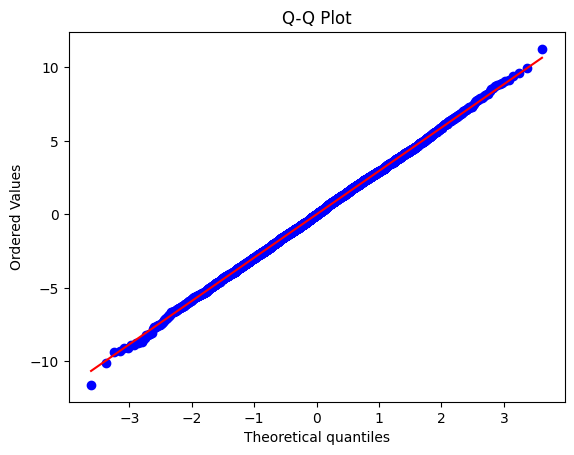

Linear Equation:
Sales = -0.1325 + 3.5615 * TV


/tmp/ipykernel_414/3216413336.py:72: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Sales = {model.params[0]:.4f} + {model.params[1]:.4f} * TV")


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from google.colab import files
import scipy.stats as stats

# Upload dataset
uploaded = files.upload()

# Load dataset
df = pd.read_csv('marketing.csv')

# Keep relevant columns
df = df[['TV','Radio','Social_Media','Sales']]

# Remove rows with missing values
df = df.dropna()

# Data Exploration
print(df.head())
print(df.info())
print(df.describe())

# Correlation Matrix
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

# Simple Linear Regression (TV vs Sales)
X = df[['TV']]
y = df['Sales']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

# Predictions
predictions = model.predict(X)

# Regression Plot
plt.figure(figsize=(8,6))
plt.scatter(df['TV'], y)
plt.plot(df['TV'], predictions)
plt.xlabel('TV Advertising')
plt.ylabel('Sales')
plt.title('Simple Linear Regression: TV vs Sales')
plt.show()

# Residual Plot
residuals = y - predictions

plt.figure(figsize=(8,6))
plt.scatter(predictions, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

# Linear Equation
print("Linear Equation:")
print(f"Sales = {model.params[0]:.4f} + {model.params[1]:.4f} * TV")